In [10]:
import pandas as pd

In [11]:
df=pd.read_csv("cleaned_data.csv")

In [12]:
X = df.drop(columns=['Dropout'])   # features
y = df['Dropout']                 # target

TRAIN TEST SPLIT

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

LOGISTIC REGRESSION

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

RANDOM FOREST

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [17]:
y_pred_rf_adj = (y_prob_rf > 0.4).astype(int)

EVALUATION

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print("===== LOGISTIC =====")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("===== RANDOM FOREST (0.4 threshold) =====")
print(confusion_matrix(y_test, y_pred_rf_adj))
print(classification_report(y_test, y_pred_rf_adj))

===== LOGISTIC =====
[[531  70]
 [ 49 235]]
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       601
           1       0.77      0.83      0.80       284

    accuracy                           0.87       885
   macro avg       0.84      0.86      0.85       885
weighted avg       0.87      0.87      0.87       885

===== RANDOM FOREST (0.4 threshold) =====
[[552  49]
 [ 58 226]]
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       601
           1       0.82      0.80      0.81       284

    accuracy                           0.88       885
   macro avg       0.86      0.86      0.86       885
weighted avg       0.88      0.88      0.88       885



Confusion matrix

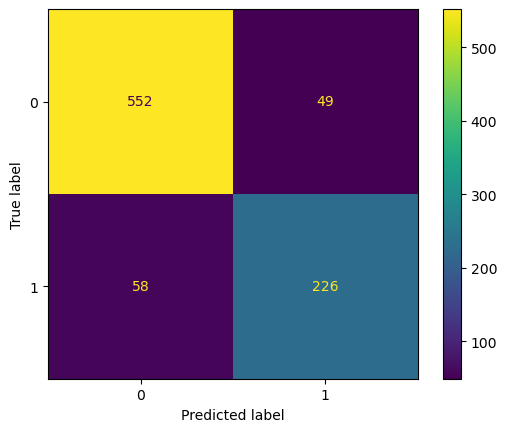

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_adj)
plt.show()

Roc curve

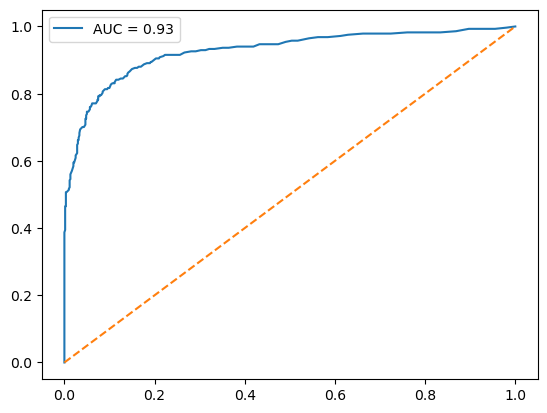

In [20]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.legend()
plt.show()

Precision recall curve

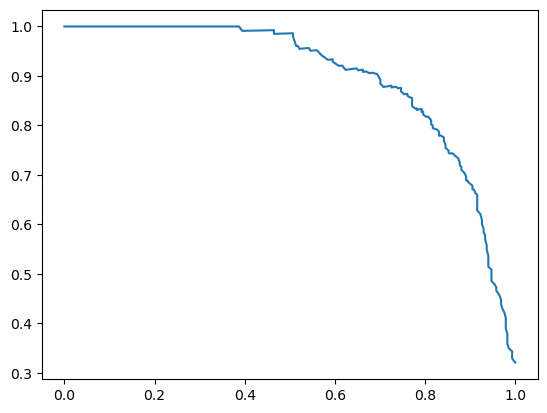

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)

plt.plot(recall, precision)
plt.show()

MODEL REFINING ON TOP FEATURES

In [24]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top Features:\n")
print(importance.head(10))

Top Features:

2nd_pass_ratio                         0.129873
total_approved                         0.092048
Curricular units 2nd sem (approved)    0.092002
1st_pass_ratio                         0.078625
Curricular units 2nd sem (grade)       0.057404
Curricular units 1st sem (grade)       0.045544
Tuition fees up to date                0.043973
Admission grade                        0.042597
Age at enrollment                      0.039880
Curricular units 1st sem (approved)    0.037986
dtype: float64


In [25]:
top_features = importance.head(10).index.tolist()
X_selected = X[top_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [27]:
y_pred_rf_adj = (y_prob_rf > 0.4).astype(int)
print(confusion_matrix(y_test, y_pred_rf_adj))
print(classification_report(y_test, y_pred_rf_adj))

[[540  61]
 [ 57 227]]
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       601
           1       0.79      0.80      0.79       284

    accuracy                           0.87       885
   macro avg       0.85      0.85      0.85       885
weighted avg       0.87      0.87      0.87       885



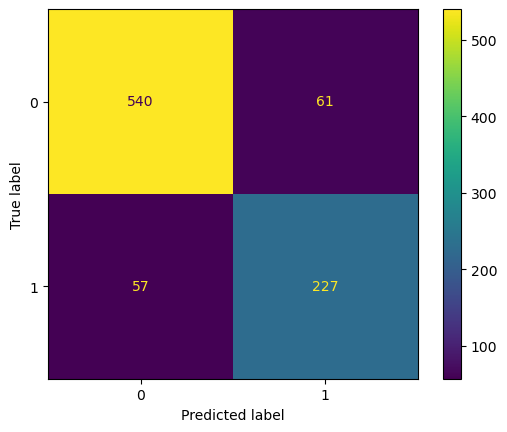

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_adj)
plt.show()

MODEL EXPORT

In [29]:
import joblib
joblib.dump(rf_model, "model.pkl")
joblib.dump(top_features, "features.pkl")

print("\nModel saved with selected features!")


Model saved with selected features!
